#Scenario 2: Diabetes Prediction (Decision Tree)
Problem Statement

We want to predict whether one of the female patients has diabetes based on medical measurements.

Target variable:

target = 1 → diabetes present

target = 0 → no diabetes

This is a binary classification problem.

---

**Dataset Description**

The dataset contains features such as:

age – age of patient

pregnencies – the number of times they've been pregnant

BMI – their rating on the Body Mass Index scale

bloodpressure – resting blood pressure

insulin – amount of insulin present

glucose – amount of glucose present


# Task: Similarly to the heart disease lab task (https://colab.research.google.com/drive/1wGA-EYf-TP43WexQjpH5rVsJp4J1ljLI?usp=sharing) , you will create a decision tree model that analyses the data from the dataset and creates a confusion matrix, a plot tree, and gives an accuracy rating.

#Step 1: Load the Dataset using Pandas

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
from sklearn.metrics import accuracy_score



In [25]:
path = r"C:\Users\LENOVO\Downloads\Lab 5 - AI-20260620T182634Z-3-001\Lab 5 - AI\Databases\diabetes_prediction_dataset.csv"
df = pd.read_csv(path)

In [26]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [27]:
df.shape

(100000, 9)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [29]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


Accuracy: 97.20%


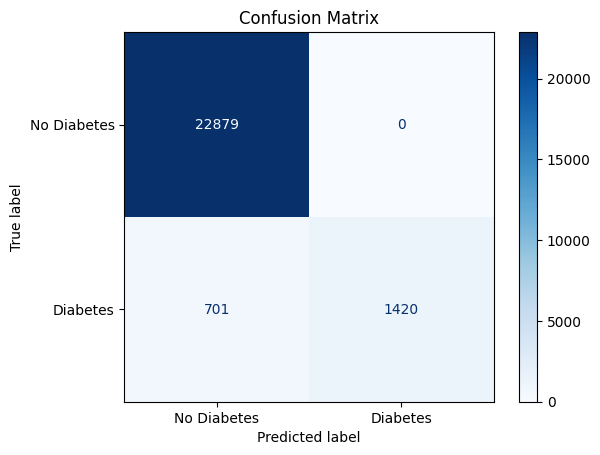

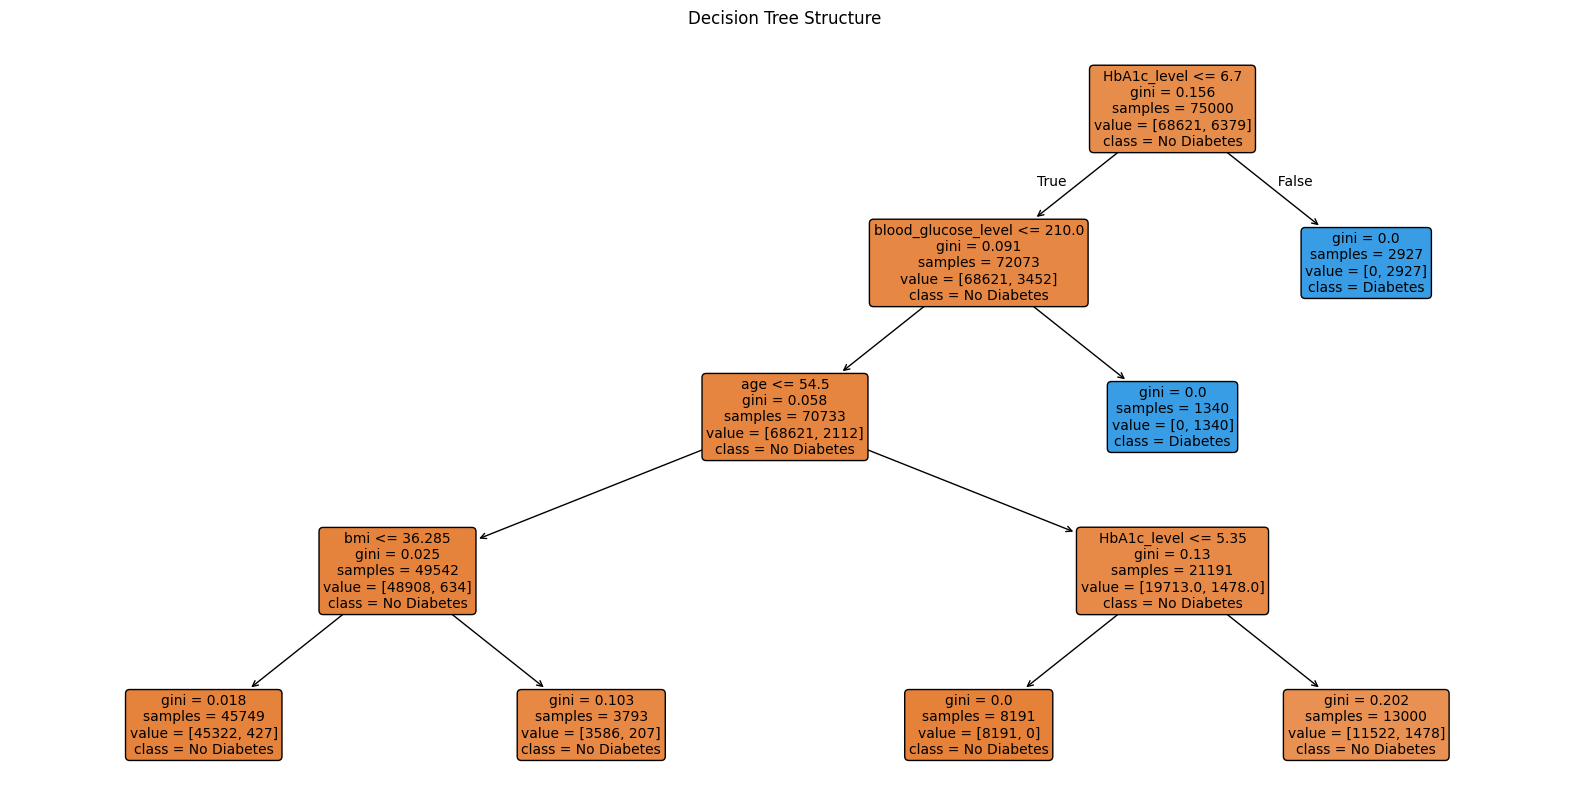

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.97      1.00      0.98     22879
    Diabetes       1.00      0.67      0.80      2121

    accuracy                           0.97     25000
   macro avg       0.99      0.83      0.89     25000
weighted avg       0.97      0.97      0.97     25000



In [34]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X = df[['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']]
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=23)

model = DecisionTreeClassifier(max_depth=4, random_state=23)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")



import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# 2. Plot the Decision Tree
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'], filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Structure")
plt.show()




from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))